# Assignment 2 - Feature extraction and classification

Note: This notebook file for the assignment has deviations from the course guide with respect to the structure, sentence framing, question framing and numbering. Please consider this notebook file structure as the final structure and follow this.

In this assignment, you are expected to

(1) extract global features from CIFAR10 dataset with one of the pre-trained neural networks available in pytorch,

(2) classify the dataset using the traditional k-Nearest Neighbours classifier,

and

(3) implement k-fold cross-validation to evaluate your model.

------------------------

In [1]:
# Load all the needed packages for this assignment here
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

When working with Pytorch, dataloader() is a must to know function. Read more about this function and the parameters it accepts in https://blog.paperspace.com/dataloaders-abstractions-pytorch/

In [2]:
from torch.utils.data import DataLoader

The variable 'transform' encapsulates the needed transformations of our data. Read more about transforms in https://blog.paperspace.com/dataloaders-abstractions-pytorch/

In [3]:
transform = transforms.Compose([
    # resize
    transforms.Resize(32),
    # center-crop
    transforms.CenterCrop(32),
    # to-tensor
    transforms.ToTensor(),
    # normalize
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

### INPUT DATASET

Load the CIFAR10 dataset from Pytorch

In [4]:
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=False)

#### Exercise 2.1 - Dataset preparation

**a)** Write a function **'train_test_split(dataset, ratio)'** which takes a dataset array as an input and returns two dataset arrays- one for training and another for testing.


In [5]:
import random

def train_test_split(dataset, ratio):
    # Arguments
    # - dataset -> Array
    # - ratio -> float between [0,1]
    # Ex. 2.1a your code here

    # get the dataset length
    n = len(dataset)

    # calculate the split point
    split_point = int(n * ratio)

    # shuffle the input data in case it was sorted by class
    random.seed(42)         # use a random seed so the results are more reproducable
    random.shuffle(dataset)

    # actually split the data
    training_data = dataset[:split_point]
    testing_data = dataset[split_point:]
    
    return training_data,testing_data

# test the function 
print(train_test_split([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15], 0.5))

([9, 14, 8, 7, 15, 13, 6], [3, 10, 4, 5, 12, 1, 2, 11])


### FEATURE EXTRACTION

Extract descriptros from the images in your train and test dataset. The dataset split should remain the same for all the experiments if you want to be fair when comparing performance.

#### Exercise 2.2 - Feature 1 - RGB descriptor

Implement the same code you wrote for extracting the overall RGB descriptors(of size n x 24) as in assignment 1 here.

In [6]:
# Ex.2.2 your code here

from tqdm import tqdm

# amount of bins for the histogram
bins = 8

# amount of samples
n_samples = len(dataset.data)

# create the empty vector that stores the RGB descriptors of all images
rgb_descriptors = np.zeros((n_samples, bins * 3))

# loop over the images
for i, img in tqdm(enumerate(dataset.data)):
    # Extract individual channels data
    r_channel = img[:, :, 0]
    g_channel = img[:, :, 1]
    b_channel = img[:, :, 2]

    # compute a histogram for each channel
    r_hist, bin_edges = np.histogram(r_channel, bins=bins, range=(0,256))
    g_hist, bin_edges = np.histogram(g_channel, bins=bins, range=(0, 256))
    b_hist, bin_edges = np.histogram(b_channel, bins=bins, range=(0, 256))
    
    # concatenate the histograms into a feature vector 
    feature_vector = np.concatenate([r_hist, g_hist, b_hist])

    
    rgb_descriptors[i] = feature_vector

print(f'RGB descriptors shape: {rgb_descriptors.shape}')

50000it [00:18, 2767.87it/s]

RGB descriptors shape: (50000, 24)


#### Exercise 2.3 - Feature 2 - Extract CNN descriptors using pre-traind networks

Load one of the pretrained network (resnet, alexnet, vgg, squeezenet, densenet, inception) from pytorch to extract global features from the images present in the dataset. 
We will use the output values from the layer present just before the fully connected layer of the deep network as a descriptor, i.e. we will remove the last fully-connected layer. Therefore, after feed-forwarding the input image through the network, we save the output as the descriptor of the image. We do this for all the images present in the dataset to get the overall CNN descriptors.

You may refer to this link for debugging purposes - https://stackoverflow.com/questions/52548174/how-to-remove-the-last-fc-layer-from-a-resnet-model-in-pytorch

In [7]:
import torch.nn as nn
from torchvision import models

# Ex.2.3 your code here
# name of the model you wish to use - it should be selected from this list
# RESNET

# download the resnet model and import it
model = models.resnet18(weights='DEFAULT')

print(f'original resnet18 classifier: {model.fc}') 

# get the input feature amount of the last layer
feature_dim = model.fc.in_features
print(f'Features of the last layer = feat dim = {feature_dim}')

# remove the last layer (fc) by replacing it with an identity layer
model.fc = nn.Identity()

# # load in the layers and star (*) unpacks them
# new_classifier = nn.Sequential(*classifier_layers) 
# print(f'new classifier: {new_classifier}') 
# model.classifier = new_classifier

# setup the model for inference using the cpu
model.eval()
model.to('cpu')

n = len(dataset)

# create the empty alexnet descriptors vector
cnn_descriptors = np.zeros((n_samples, feature_dim), dtype=np.float32)

# itterate over the images and collect features
with torch.no_grad():
    for batch_i, (imgs, _) in enumerate(dataloader):
        start = batch_i * dataloader.batch_size
        end = start + imgs.size(0)

        output = model(imgs.to('cpu'))
        output = output.cpu()
        output_np = output.numpy()
        cnn_descriptors[start:end] = output_np

print(f'CNN descriptors: {cnn_descriptors.shape} ')

original resnet18 classifier: Linear(in_features=512, out_features=1000, bias=True)
Features of the last layer = feat dim = 512
CNN descriptors: (50000, 512) 


### PERFORMANCE EVALUATION

#### Exercise 2.4 - Error function

Implement a function to evaluate the accuracy of your prediction. We will rely on the evaluation metric 'accuracy'.

You are suggested to also use f-score, recall and precision. Have a look at https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html 

In [8]:
def accuracy_metric(actual, predicted):
    
    # Ex.2.4 your code here
    # accuracy = true_predictions / all predictions
    actual = np.array(actual)
    predicted = np.array(predicted)
    accuracy = np.mean(actual == predicted)
    return accuracy

### TRAIN AND TEST YOUR MODEL

#### Exercise 2.5 - k Nearest Neighbour model

For this exercise, first split the extracted overall RGB and CNN descriptor to train and test sets with the help of the 'train_test_split()' function that you implemented before.

**a)** Apply the classifier with different values of k (number of nearest neighbours) to the train **RGB descriptor** set and evaluate the performance of your models using the accuracy_metric() function that you implemented before.

You can have a look at the documentation to understand the parameters that define the learning of the model,
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

# Use your k-NN - play with the value of the parameters to see how the model performs
kvalue_list = [2,4,6,10,15] 

# Ex.2.5a your code here
labels = np.array(dataset.targets)
combined_rgb = np.hstack((rgb_descriptors, labels.reshape(-1,1)))

# Splitting into train and test dataset
rgb_train, rgb_test = train_test_split(combined_rgb, 0.8)
# print(rgb_train[:10])

# train sets
X_rgb_train = rgb_train[:, :-1]
y_rgb_train = rgb_train[:, -1]

# test sets
X_rgb_test = rgb_test[:, :-1]
y_rgb_test = rgb_test[:, -1]

# print(X_rgb_train)
# print(y_rgb_train)

best_f1 = -1
best_rgb_classifier = None
best_rgb_k = None

for k in range(1,25):
    # fit the model
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X_rgb_train, y_rgb_train)

    # run inference on the test set
    y_pred = neigh.predict(X_rgb_test)

    # check the accuracy for this k value
    accuracy = accuracy_metric(y_rgb_test, y_pred)

    prec, rec, f1, _ = precision_recall_fscore_support(y_rgb_test, y_pred, average = 'weighted', zero_division=0)

    # save the model if its better
    if f1 > best_f1:
        best_f1 = f1
        best_rgb_classifier = neigh
        best_rgb_k = k

    # add a space to format a nice table
    if k < 10:
        k_string = str(k) + str(' ')
    else: 
        k_string = str(k)

    # print to the console 
    print(f'K = {k_string}   |   acc={accuracy:.4f}  |   precision={prec:.4f}    |   recall = {rec:.4f}  |   f1={f1:.4f}')
# print(neigh.predict([[1.1]]))

print(f'Best F1 score found at k={best_rgb_k} with an F1={best_f1}')

K = 1    |   acc=0.5835  |   precision=0.5851    |   recall = 0.5835  |   f1=0.5837
K = 2    |   acc=0.4973  |   precision=0.5116    |   recall = 0.4973  |   f1=0.4945
K = 3    |   acc=0.4547  |   precision=0.4597    |   recall = 0.4547  |   f1=0.4542
K = 4    |   acc=0.4241  |   precision=0.4277    |   recall = 0.4241  |   f1=0.4226
K = 5    |   acc=0.3989  |   precision=0.4027    |   recall = 0.3989  |   f1=0.3981
K = 6    |   acc=0.3790  |   precision=0.3837    |   recall = 0.3790  |   f1=0.3780
K = 7    |   acc=0.3656  |   precision=0.3694    |   recall = 0.3656  |   f1=0.3648
K = 8    |   acc=0.3555  |   precision=0.3583    |   recall = 0.3555  |   f1=0.3543
K = 9    |   acc=0.3550  |   precision=0.3581    |   recall = 0.3550  |   f1=0.3539
K = 10   |   acc=0.3479  |   precision=0.3509    |   recall = 0.3479  |   f1=0.3466
K = 11   |   acc=0.3431  |   precision=0.3465    |   recall = 0.3431  |   f1=0.3416
K = 12   |   acc=0.3420  |   precision=0.3453    |   recall = 0.3420  |   f1

**b)** Apply the classifier with different values of k (number of nearest neighbours) to the train **CNN descriptor** and evaluate the performance of your models using the accuracy_metric() function that you implemented before.

In [10]:
# Ex.2.5b your code 
labels = np.array(dataset.targets)

# split into train and test
combined_cnn = np.hstack((cnn_descriptors, labels.reshape(-1,1)))

cnn_train, cnn_test = train_test_split(combined_cnn, 0.8)

# split into x and y 
X_cnn_train = cnn_train[:, :-1]
y_cnn_train = cnn_train[:, -1]

X_cnn_test = cnn_test[:, :-1]
y_cnn_test = cnn_test[:, -1]

print(X_cnn_train)
print(y_cnn_train)

best_f1 = -1
best_cnn_classifier = None 
best_cnn_k = None

for k in range(1,25):
    # fit the model
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X_cnn_train, y_cnn_train)

    # run inference on the test set
    y_cnn_pred = neigh.predict(X_cnn_test)

    # check the accuracy for this k value
    accuracy = accuracy_metric(y_cnn_test, y_cnn_pred)

    prec, rec, f1, _ = precision_recall_fscore_support(y_cnn_test, y_cnn_pred, average = 'weighted', zero_division=0)

    # save the model if its better
    if f1 > best_f1:
        best_f1 = f1
        best_cnn_classifier = neigh
        best_cnn_k = k

    # add a space to format a nice table
    if k < 10:
        k_string = str(k) + str(' ')
    else: 
        k_string = str(k)

    # print to the console 
    print(f'K = {k_string}   |   acc={accuracy:.4f}  |   precision={prec:.4f}    |   recall = {rec:.4f}  |   f1={f1:.4f}')
# print(neigh.predict([[1.1]]))

print(f'Best F1 score found at k={best_cnn_k} with an F1={best_f1}')

[[1.51836979 0.12119222 0.         ... 2.9277029  0.65706825 0.        ]
 [1.51836979 0.12119222 0.         ... 2.9277029  0.65706825 0.        ]
 [0.         0.         0.         ... 0.56099057 1.43088174 0.        ]
 ...
 [0.         0.43042439 0.29370809 ... 2.83263826 0.40847051 0.        ]
 [0.39941603 0.96453178 1.47105002 ... 1.21478248 0.         0.        ]
 [0.28753442 0.         0.         ... 1.33211303 0.52716476 0.        ]]
[6. 6. 9. ... 8. 7. 0.]
K = 1    |   acc=0.6953  |   precision=0.6954    |   recall = 0.6953  |   f1=0.6948
K = 2    |   acc=0.6391  |   precision=0.6461    |   recall = 0.6391  |   f1=0.6384
K = 3    |   acc=0.6035  |   precision=0.6039    |   recall = 0.6035  |   f1=0.6029
K = 4    |   acc=0.5772  |   precision=0.5785    |   recall = 0.5772  |   f1=0.5766
K = 5    |   acc=0.5680  |   precision=0.5681    |   recall = 0.5680  |   f1=0.5673
K = 6    |   acc=0.5586  |   precision=0.5589    |   recall = 0.5586  |   f1=0.5575
K = 7    |   acc=0.5568  |  

#### Exercise 2.6 - Visualize results 

**a)** Since you already applied PCA to the extracted overall RGB descriptor in assignment 1, now apply PCA to the extracted overall **CNN descriptor**.

Steps to follow:

1) Choose the kNN classifier with k value that gave you the best results in the previous exercise and use it to make predictions on your train CNN descriptor set.

2) Apply PCA on the train set and select the first 2 principal components to represent each sample.

2) Plot the principal components representing the samples with empty circles. Use one color per ground truth class lables. On top of this, plot the samples again but now with filled circles. For these filled circles, use the color of the class predicted per sample in step 1. You can note that misclassifications will make the colours not coincide.

Train accuracy:  1.0000
Train precision: 1.0000
Train recall:    1.0000
Train F1:        1.0000


C:\Users\valen\AppData\Local\Temp\ipykernel_19788\1580573376.py:47: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pca_results[m_pr,0], pca_results[m_pr,1], s=15, c=colors[i], alpha=0.6)


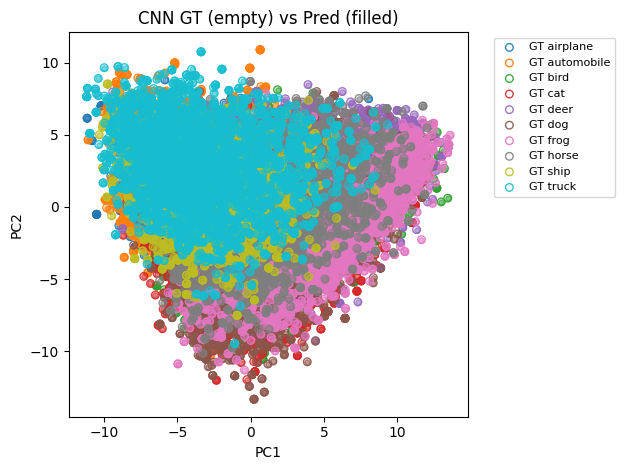

In [16]:
# Ex.2.6a your code her
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# load the best classifier
clf = best_cnn_classifier

# run predictions on the train set
y_cnn_pred_train = clf.predict(X_cnn_train)

# stats for the prediction of train data
acc = accuracy_score(y_cnn_train, y_cnn_pred_train)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_cnn_train, y_cnn_pred_train, average="weighted", zero_division=0
)

print(f"Train accuracy:  {acc:.4f}")
print(f"Train precision: {prec:.4f}")
print(f"Train recall:    {rec:.4f}")
print(f"Train F1:        {f1:.4f}")

# apply pca on train 
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(X_cnn_train)

# plotting the gt empty circles and predictions fulled and missclassified marked
colors = plt.cm.tab10(np.arange(10))

fig, ax = plt.subplots()

classes = dataset.classes

# loop over the classes
for i, class_ in enumerate(classes):

    # selec the samples where gt = c -> put these into an arras as a mask
    mask_gt = (y_cnn_train == i)

    # plot each with the color
    ax.scatter(pca_results[mask_gt,0], pca_results[mask_gt,1], s=30, facecolors='none',
               edgecolors=[colors[i]], label=f'GT {class_}', alpha=0.9)
    
    # selec the samples where that are predicted to be the class
    m_pr = (y_cnn_pred_train == i)

    # plot those 
    ax.scatter(pca_results[m_pr,0], pca_results[m_pr,1], s=15, c=colors[i], alpha=0.6)

# select the incorrectly classified samples
mis = (y_cnn_train != y_cnn_pred_train)

# plot an x on them 
if mis.any():
    ax.scatter(
        pca_results[mis,0], 
        pca_results[mis,1], 
        s=28, 
        c='k', 
        marker='x', 
        label='misclassified'
    )


# finish the graph
ax.set_title('CNN GT (empty) vs Pred (filled)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left', markerscale=1, fontsize=8)
plt.tight_layout()
plt.show()

**b)** Repeat the steps mentioned before but now on the test CNN descriptor set. 

Test accuracy:  0.6953
Test precision: 0.6954
Test recall:    0.6953
Test F1:        0.6948


C:\Users\valen\AppData\Local\Temp\ipykernel_19788\3651221048.py:47: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pca_results[m_pr,0], pca_results[m_pr,1], s=15, c=colors[i], alpha=0.6)


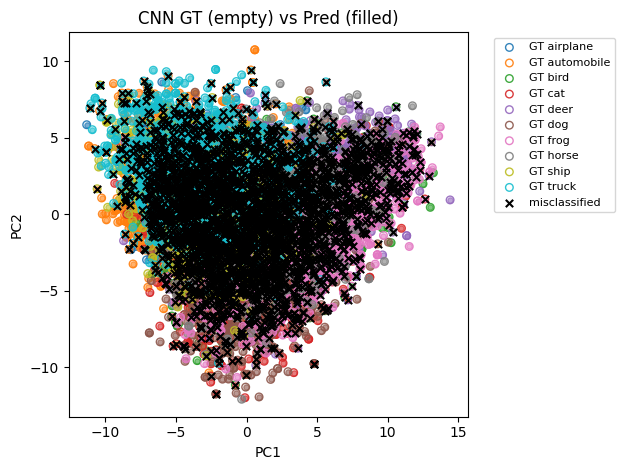

In [17]:
# Ex.2.6a your code her
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# load the best classifier
clf = best_cnn_classifier

# run predictions on the test set
y_cnn_pred_test = clf.predict(X_cnn_test)

# stats for the prediction of train data
acc = accuracy_score(y_cnn_test, y_cnn_pred_test)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_cnn_test, y_cnn_pred_test, average="weighted", zero_division=0
)

print(f"Test accuracy:  {acc:.4f}")
print(f"Test precision: {prec:.4f}")
print(f"Test recall:    {rec:.4f}")
print(f"Test F1:        {f1:.4f}")

# apply pca on test 
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(X_cnn_test)

# plotting the gt empty circles and predictions fulled and missclassified marked
colors = plt.cm.tab10(np.arange(10))

fig, ax = plt.subplots()

classes = dataset.classes

# loop over the classes
for i, class_ in enumerate(classes):

    # selec the samples where gt = c -> put these into an arras as a mask
    mask_gt = (y_cnn_test == i)

    # plot each with the color
    ax.scatter(pca_results[mask_gt,0], pca_results[mask_gt,1], s=30, facecolors='none',
               edgecolors=[colors[i]], label=f'GT {class_}', alpha=0.9)
    
    # selec the samples where that are predicted to be the class
    m_pr = (y_cnn_pred_test == i)

    # plot those 
    ax.scatter(pca_results[m_pr,0], pca_results[m_pr,1], s=15, c=colors[i], alpha=0.6)

# select the incorrectly classified samples
mis = (y_cnn_test != y_cnn_pred_test)

# plot an x on them 
if mis.any():
    ax.scatter(
        pca_results[mis,0], 
        pca_results[mis,1], 
        s=28, 
        c='k', 
        marker='x', 
        label='misclassified'
    )


# finish the graph
ax.set_title('CNN GT (empty) vs Pred (filled)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left', markerscale=1, fontsize=8)
plt.tight_layout()
plt.show()

#### Exercise 2.7 - kNN with k-Fold cross-validation

Assess the performance of your implemented kNN using k-Fold cross-validation. 

Run your implemented function evaluating for k (fold) = 2, 5 and 10. You can rely on the kNN that performed best in the previous exercises.
Report the average accuracy and the standard deviation.

In [25]:
# Load packages
from sklearn.model_selection import KFold
import numpy as np
from sklearn.utils import shuffle

# Ex.2.7 your code here

#setup the data
x = cnn_descriptors
y = np.array(dataset.targets)

# use the best knn
folds = [2,5,10]
results = {}

for fold in folds:
    kf = KFold(n_splits=fold, shuffle=True)
    accuracies = []

    for fold_id, (train_i, test_i) in enumerate(kf.split(x), start=1):
        # split data into sets
        x_train = x[train_i]
        y_train = y[train_i]

        x_test = x[test_i]
        y_test = y[test_i]

        # setup the classifier
        clf = KNeighborsClassifier(n_neighbors=best_cnn_k)
        clf.fit(x_train, y_train)

        # run predictions on test
        y_test_pred = clf.predict(x_test)
        accuracy = accuracy_score(y_test, y_test_pred)

        accuracies.append(accuracy)

        print(f" Fold: {fold} | Fold_id: {fold_id}: acc = {accuracy:4f}")

    results[fold] = accuracies

avg_acc_list = []
k_list = []
# convert data to 
for k in folds:
    k_list.append(k)
    avg_acc_list.append(results[k])

 Fold: 2 | Fold_id: 1: acc = 0.471160
 Fold: 2 | Fold_id: 2: acc = 0.478080
 Fold: 5 | Fold_id: 1: acc = 0.500900
 Fold: 5 | Fold_id: 2: acc = 0.492700
 Fold: 5 | Fold_id: 3: acc = 0.497300
 Fold: 5 | Fold_id: 4: acc = 0.490300
 Fold: 5 | Fold_id: 5: acc = 0.491700
 Fold: 10 | Fold_id: 1: acc = 0.493000
 Fold: 10 | Fold_id: 2: acc = 0.498000
 Fold: 10 | Fold_id: 3: acc = 0.504200
 Fold: 10 | Fold_id: 4: acc = 0.495400
 Fold: 10 | Fold_id: 5: acc = 0.506400
 Fold: 10 | Fold_id: 6: acc = 0.499600
 Fold: 10 | Fold_id: 7: acc = 0.506400
 Fold: 10 | Fold_id: 8: acc = 0.498600
 Fold: 10 | Fold_id: 9: acc = 0.499600
 Fold: 10 | Fold_id: 10: acc = 0.498200


In [29]:
## SUGGESTION ON HOW TO PRESENT PERFORMANCE OF YOUR KFOLD CROSS VALIDATION ANALYSIS

print('Summary results:')
print(' ')
for i,k in enumerate(k_list):
    print(k,'-fold cross validation:')  
    print('Accuracies per fold: ', avg_acc_list[i]) 
    
    avg_acc = round(sum(avg_acc_list[i])/k,3)
    std_list= round(np.std(avg_acc_list[i]),5)
    print('Average accuracy: ', avg_acc,'+-', std_list) 
    print(' ')

Summary results:
 
2 -fold cross validation:
Accuracies per fold:  [0.47116, 0.47808]
Average accuracy:  0.475 +- 0.00346
 
5 -fold cross validation:
Accuracies per fold:  [0.5009, 0.4927, 0.4973, 0.4903, 0.4917]
Average accuracy:  0.495 +- 0.00394
 
10 -fold cross validation:
Accuracies per fold:  [0.493, 0.498, 0.5042, 0.4954, 0.5064, 0.4996, 0.5064, 0.4986, 0.4996, 0.4982]
Average accuracy:  0.5 +- 0.00423
 


### [Optional] Exercise: further explore by: 
- implement other classifiers such as SVM or Random Forest, 
- extract other descriptors from the images such as objects or other local features,
- implement the evaluation metrics: recall, precision and f-score.